<a href="https://colab.research.google.com/github/jc020230/2026-1-theory-practice/blob/main/hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.27.1 which is incompatible.


In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"

Q1. original model, lower capacity model, higher capacity model을 각각 20 epoch 정도 학습시킨 후, validation loss를 하나의 그래프에 그려보고 비교해보세요.

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


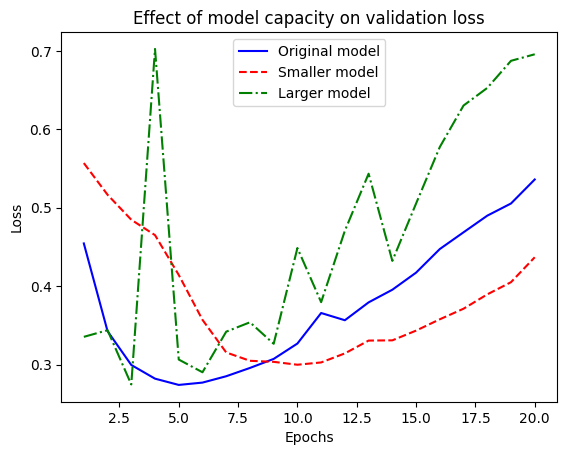

In [ ]:
from keras.datasets import imdb
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

# 1. Original Model (16 units)
model_original = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_original.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_original = model_original.fit(train_data, train_labels, epochs=20, batch_size=512, validation_split=0.4, verbose=0)

# 2. Smaller Model (Lower capacity: 4 units)
model_smaller = keras.Sequential([
    layers.Dense(4, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_smaller.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_smaller_model = model_smaller.fit(train_data, train_labels, epochs=20, batch_size=512, validation_split=0.4, verbose=0)

# 3. Larger Model (Higher capacity: 512 units)
model_larger = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_larger.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_larger_model = model_larger.fit(train_data, train_labels, epochs=20, batch_size=512, validation_split=0.4, verbose=0)

# 4. 시각화 (Validation Loss 비교)
epochs = range(1, 21)
plt.plot(epochs, history_original.history["val_loss"], "b-", label="Original model")
plt.plot(epochs, history_smaller_model.history["val_loss"], "r--", label="Smaller model")
plt.plot(epochs, history_larger_model.history["val_loss"], "g-.", label="Larger model")
plt.title("Effect of model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

비교 결과:
Higher capacity : 모델이 너무 복잡하여 첫 1~2번의 epoch 만에 빠르게 Overfitting이 시작되며 Validation Loss가 요동치다가 급격히 높아집니다.

Lower capacity : 4 units를 사용한 만큼 loss가 크게 요동치지 않고 안정적입니다. overfitting이 늦게 일어나고, original에 비해 더 완만한 그래프를 보입니다. 다만 epoch을 더 높게 설정할 경우 original에 비해 잘 학습하지 못해 전반적인 손실 값이 Original 모델보다 높게 유지될 수 있습니다.

Original : 두 모델의 중간 형태로, 적절한 시점까지 학습을 진행한 후 천천히 과대적합이 발생합니다

Q2. original 모형, l2 regularization 기법 적용 모형, dropout 적용 모형들을 20 epoch 정도 학습시킨 후, validation loss를 하나의 그래프에 그려보고 비교해 보세요. (l2 regularization, dropout 관련 파라미터는 임의로 설정)



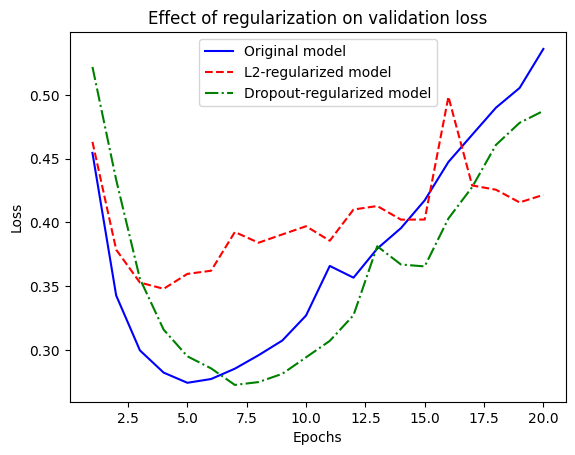

In [ ]:
from keras import regularizers

# 1. L2 Regularization Model (0.002로 설정)
model_l2 = keras.Sequential([
    layers.Dense(16, kernel_regularizer=regularizers.l2(0.002), activation="relu"),
    layers.Dense(16, kernel_regularizer=regularizers.l2(0.002), activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_l2.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_l2_reg = model_l2.fit(train_data, train_labels, epochs=20, batch_size=512, validation_split=0.4, verbose=0)

# 2. Dropout Model (0.5로 설정)
model_dropout = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
model_dropout.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_dropout = model_dropout.fit(train_data, train_labels, epochs=20, batch_size=512, validation_split=0.4, verbose=0)

# 3. 시각화 (Validation Loss 비교)
plt.plot(epochs, history_original.history["val_loss"], "b-", label="Original model")
plt.plot(epochs, history_l2_reg.history["val_loss"], "r--", label="L2-regularized model")
plt.plot(epochs, history_dropout.history["val_loss"], "g-.", label="Dropout-regularized model")
plt.title("Effect of regularization on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Dropout이나 l2 regularization 둘 다 overfitting을 방지하기 위한 기법인 만큼. Q1의 그래프나 Q2의 original에 비해 더 안정적인 모습을 보입니다.

original의 경우 특정 기점까지 학습을 하다가 overfitting이 되어 validation loss가 점점 상승하는 것을 보입니다.

dropout, l2 regularization의 경우, 그래프가 더 평탄하거나, overfitting이 나는 특정 기점이 original model보다 더욱 늦은 것을 볼 수 있습니다.

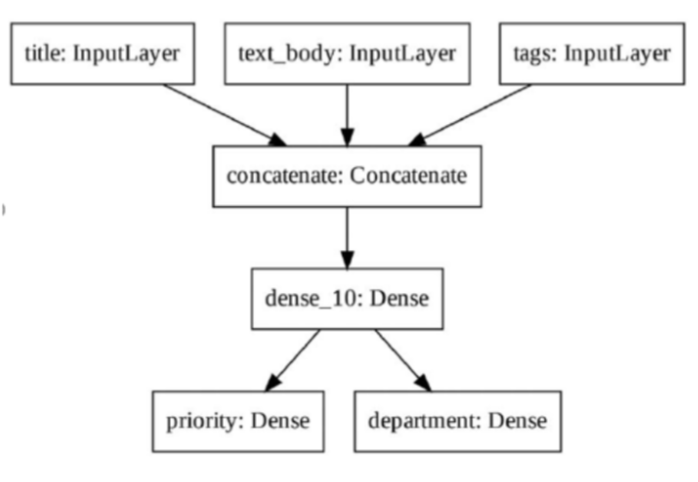

Q3. 위에 기본 모형을 변경하여 다양한 구조를 만들어보고 더미데이터를 만들어서 에러 없이 학습을 시켜보세요.

In [ ]:
vocabulary_size = 10000
num_tags = 100
num_departments = 4

title = keras.Input(shape=(vocabulary_size,), name="title")
text_body = keras.Input(shape=(vocabulary_size,), name="text_body")
tags = keras.Input(shape=(num_tags,), name="tags")

# (Concatenate 이후 중간 은닉층 추가)
features = layers.Concatenate()([title, text_body, tags])
features = layers.Dense(64, activation="relu", name="dense_features")(features)
# 32 units dense layer 추가
features = layers.Dense(32, activation="relu", name="extra_features")(features)

priority = layers.Dense(1, activation="sigmoid", name="priority")(features)
department = layers.Dense(num_departments, activation="softmax", name="department")(features)

model_multi = keras.Model(inputs=[title, text_body, tags], outputs=[priority, department])
model_multi.compile(
    optimizer="rmsprop",
    loss={
        "priority": "binary_crossentropy",
        "department": "categorical_crossentropy"
    },
    metrics={
        "priority": ["accuracy"],
        "department": ["accuracy"]
    }
)

In [ ]:
# Create Dummy data
num_samples = 1280

dummy_title = np.random.random(size=(num_samples, vocabulary_size))
dummy_text_body = np.random.random(size=(num_samples, vocabulary_size))
dummy_tags = np.random.random(size=(num_samples, num_tags))

dummy_priority = np.random.random(size=(num_samples, 1))
dummy_department = np.random.random(size=(num_samples, num_departments))

# train dummy data
model_multi.fit(
    {"title": dummy_title, "text_body": dummy_text_body, "tags": dummy_tags},
    {"priority": dummy_priority, "department": dummy_department},
    epochs=5,
    batch_size=128
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - department_accuracy: 0.0000e+00 - department_loss: 21.7927 - loss: 28.9388 - priority_accuracy: 0.0000e+00 - priority_loss: 7.1461
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - department_accuracy: 0.0000e+00 - department_loss: 24.3208 - loss: 32.1734 - priority_accuracy: 0.0000e+00 - priority_loss: 7.8525 
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - department_accuracy: 0.0000e+00 - department_loss: 24.3208 - loss: 32.1734 - priority_accuracy: 0.0000e+00 - priority_loss: 7.8525 
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - department_accuracy: 0.0000e+00 - department_loss: 24.3208 - loss: 32.1734 - priority_accuracy: 0.0000e+00 - priority_loss: 7.8525
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - department_accuracy: 0.0000e+00 - department_loss: 24.3208 - loss: 32.1734 - priority_accuracy: 0.0000e+00 - priority_loss: 7.8525
